In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip "/content/drive/MyDrive/flower.zip" -d /content/

In [ ]:
import os
dataset_path = "/content/flowers"

print(os.listdir(dataset_path))

['tulip', 'sunflower', 'daisy', 'dandelion', 'rose']


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG19
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
import numpy as np
import matplotlib.pyplot as plt
import random
import os

In [ ]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

In [ ]:
train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 3457 images belonging to 5 classes.
Found 860 images belonging to 5 classes.


In [ ]:
vgg = VGG19(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze base model
for layer in vgg.layers:
    layer.trainable = False

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
model = Sequential([
    vgg,
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(train_data.num_classes, activation='softmax')
])

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=2
)

Epoch 1/2
109/109 ━━━━━━━━━━━━━━━━━━━━ 58s 396ms/step - accuracy: 0.5473 - loss: 1.6554 - val_accuracy: 0.6953 - val_loss: 0.8433
Epoch 2/2
109/109 ━━━━━━━━━━━━━━━━━━━━ 30s 272ms/step - accuracy: 0.6879 - loss: 0.8137 - val_accuracy: 0.7686 - val_loss: 0.7141


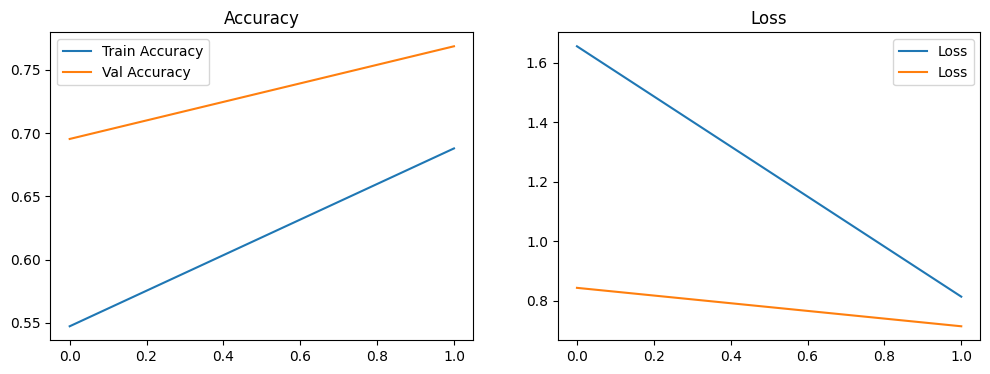

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Loss')
plt.plot(history.history['val_loss'], label='Loss')
plt.legend()
plt.title("Loss")

plt.show()

In [ ]:
class_names = list(train_data.class_indices.keys())
print(class_names)

['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Image 1: tulip | True: tulip | 97.81% (High)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
Image 2: daisy | True: daisy | 69.20% (Medium)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Image 3: daisy | True: daisy | 66.55% (Medium)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Image 4: tulip | True: daisy | 41.64% (Low)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Image 5: daisy | True: daisy | 61.89% (Medium)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Image 6: tulip | True: tulip | 66.15% (Medium)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Image 7: tulip | True: dandelion | 26.53% (Low)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Image 8: dandelion | True: dandelion | 99.84% (High)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Image 9: tulip | True: tulip | 64.29% (Medium)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Image 10: dandelion | True: dandelion | 93.63% (High)


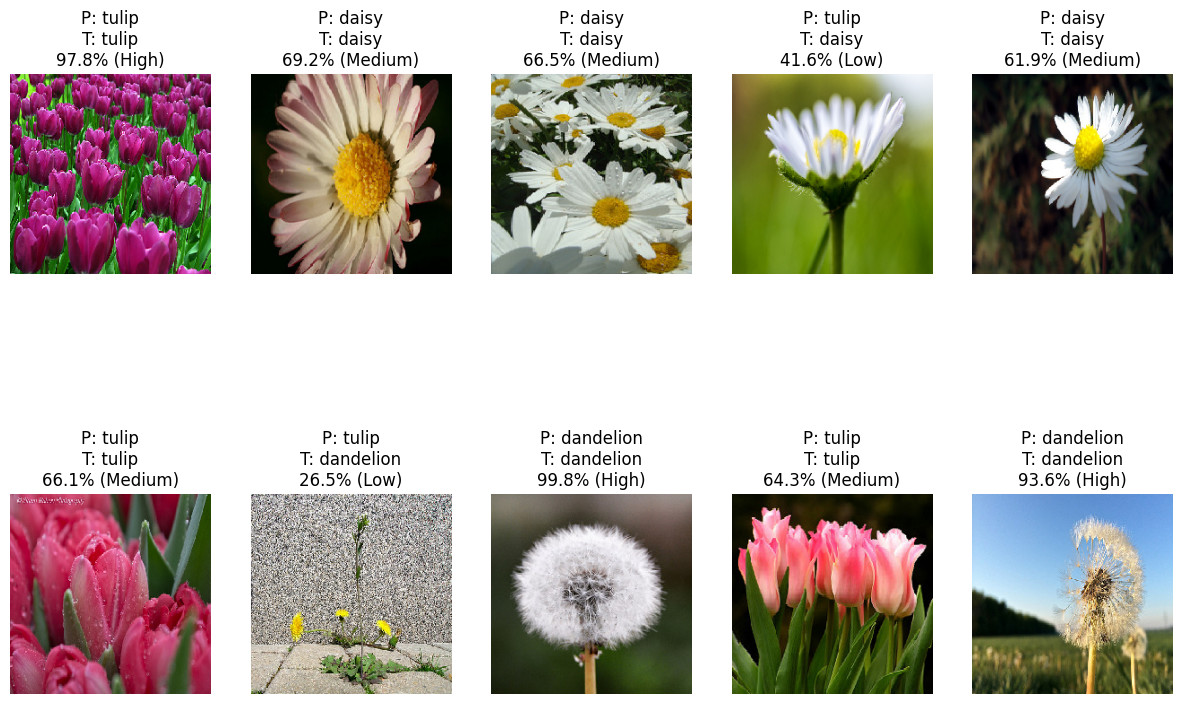

In [ ]:
images, labels = next(val_data)

plt.figure(figsize=(15,10))

for i in range(10):
    img = images[i]

    pred = model.predict(np.expand_dims(img, axis=0))

    predicted_index = np.argmax(pred)
    predicted_class = class_names[predicted_index]

    true_class = class_names[np.argmax(labels[i])]

    confidence = np.max(pred) * 100

    if confidence >= 80:
        level = "High"
    elif confidence >= 50:
        level = "Medium"
    else:
        level = "Low"

    print(f"Image {i+1}: {predicted_class} | True: {true_class} | {confidence:.2f}% ({level})")

    plt.subplot(2,5,i+1)
    plt.imshow(img)
    plt.title(f"P: {predicted_class}\nT: {true_class}\n{confidence:.1f}% ({level})")
    plt.axis("off")

plt.show()